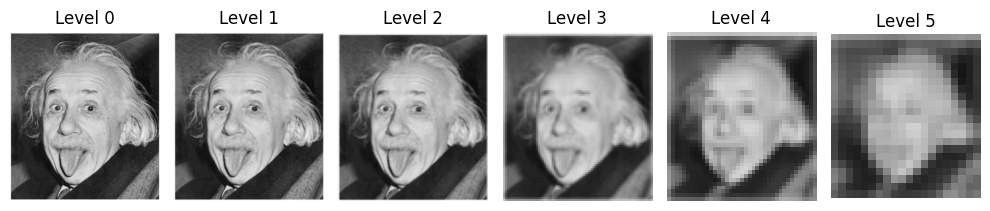

In [ ]:
# apply Gaussian image pyramid to the image
# Gaussian image pyramids are created by downsampling an image and applying a Gaussian filter to each level.
# Adjust the number of levels in the for loop as needed to create a pyramid with the desired number of levels.
# This code demonstrates downsampling the image using cv2.pyrDown() to generate a Gaussian image pyramid and then displays each level of the pyramid using Matplotlib.

import cv2
import matplotlib.pyplot as plt

# Read the image
path = r'/content/drive/MyDrive/CVClassLectureDemo/Einstein.JPG'
# path = r'/content/drive/MyDrive/CVClassLectureDemo/lena_g.JPG'
image = cv2.imread(path) # Replace path with your image filename
#image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB

# Create a list to store pyramid images
pyramid_images = [image]

# Generate the Gaussian pyramid
for i in range(5):  # Adjust the number of levels as needed
    image = cv2.pyrDown(image)# cv2.pyrDown() function in OpenCV is used to downsample an image by reducing its size to half.
    # When you apply cv2.pyrDown() to an image, it reduces the dimensions by half along both the width and height.
    pyramid_images.append(image)

# Display the images in the pyramid using matplotlib
plt.figure(figsize=(10, 6))

for i, img in enumerate(pyramid_images):
    plt.subplot(1, len(pyramid_images), i + 1)
    plt.imshow(img)
    plt.title(f"Level {i}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Laplacian image pyramids are created by constructing Gaussian pyramids for an image and then reconstructing the original image from these pyramids.
# This code demonstrates how to generate a Laplacian pyramid from a Gaussian pyramid and then reconstruct the original image.
# Adjust the number of levels in the pyramid creation and reconstruction loops as needed.

# Read the image
# path = r'/content/drive/MyDrive/CVClassLectureDemo/lena_g.JPG'
path = r'/content/drive/MyDrive/CVClassLectureDemo/Einstein.JPG'
image = cv2.imread(path) # Replace path with your image filename
# image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB

# Generate the Gaussian pyramid
layer = image.copy()
gaussian_pyramid = [layer]
for i in range(5):  # Adjust the number of levels as needed
    layer = cv2.pyrDown(layer)
    gaussian_pyramid.append(layer)

# Generate the Laplacian pyramid
laplacian_pyramid = [gaussian_pyramid[5]]  # Initialize with the top layer of the Gaussian pyramid

# print(laplacian_pyramid)
for i in range(5, 0, -1):
    expanded = cv2.pyrUp(gaussian_pyramid[i])
    gaussian_pyramid[i - 1] = gaussian_pyramid[i - 1].resize(expanded.shape)
    # gaussian_pyramid[i - 1] = cv2.resize(gaussian_pyramid[i - 1], expanded.shape, interpolation = cv2.INTER_LINEAR)
    # print(expanded.shape)
    # print(gaussian_pyramid[i - 1].shape)
    laplacian = cv2.subtract(gaussian_pyramid[i - 1], expanded)
    laplacian_pyramid.append(laplacian)

# Display the images in the pyramid using matplotlib
plt.figure(figsize=(10, 6))

for i, img in enumerate(laplacian_pyramid):
    plt.subplot(1, len(laplacian_pyramid), i + 1)
    plt.imshow(img)
    plt.title(f"Level {i}")
    plt.axis('off')

plt.tight_layout()
plt.show()

# Reconstruct the original image from the Laplacian pyramid
reconstructed_image = laplacian_pyramid[0]
for i in range(1, 6):  # Adjust the number of levels as needed
    expanded = cv2.pyrUp(reconstructed_image)
    reconstructed_image = cv2.add(laplacian_pyramid[i], expanded)

# Display the images using matplotlib
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title('Original Image'), plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(reconstructed_image)
plt.title('Reconstructed Image'), plt.axis('off')

plt.tight_layout()
plt.show()

error: OpenCV(4.11.0) /io/opencv/modules/core/src/arithm.cpp:1139: error: (-215:Assertion failed) _src1.empty() == _src2.empty() in function 'subtract'


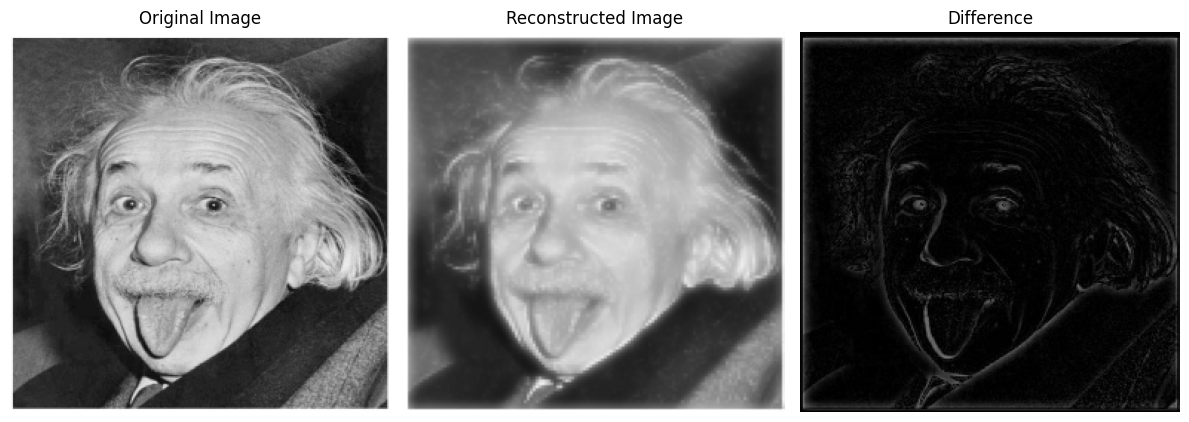

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load an image and resize for simplicity
path = r'/content/drive/MyDrive/CVClassLectureDemo/Einstein.JPG'
img = cv2.imread(path)  # replace with your image path
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (256, 256))

# Number of levels in the pyramid
levels = 2

# 1. Generate Gaussian Pyramid
gaussian_pyramid = [img.copy()]
for i in range(levels):
    img = cv2.pyrDown(img)
    gaussian_pyramid.append(img)

# 2. Generate Laplacian Pyramid
laplacian_pyramid = []
for i in range(levels, 0, -1):
    GE = cv2.pyrUp(gaussian_pyramid[i], dstsize=gaussian_pyramid[i-1].shape[:2][::-1])
    L = cv2.subtract(gaussian_pyramid[i-1], GE)
    laplacian_pyramid.append(L)

# 3. Reconstruct the image from Laplacian Pyramid
# 3. Reconstruct the image from Laplacian Pyramid
reconstructed_image = gaussian_pyramid[-1]  # smallest image
for i in range(levels-1, -1, -1):
    reconstructed_image = cv2.pyrUp(reconstructed_image)
    # Resize to match Laplacian level exactly
    reconstructed_image = cv2.resize(reconstructed_image, (laplacian_pyramid[i].shape[1], laplacian_pyramid[i].shape[0]))
    reconstructed_image = cv2.add(reconstructed_image, laplacian_pyramid[i])

# 4. Show results
# 4. Show results
plt.figure(figsize=(12, 8))

plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(gaussian_pyramid[0])
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Reconstructed Image")
plt.imshow(reconstructed_image)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Difference")
# Resize to match original if needed
reconstructed_image = cv2.resize(reconstructed_image, (gaussian_pyramid[0].shape[1], gaussian_pyramid[0].shape[0]))
difference = cv2.absdiff(gaussian_pyramid[0], reconstructed_image)
plt.imshow(difference)
plt.axis('off')

plt.tight_layout()
plt.show()